In [1]:
import torch
from transformers import GPT2Tokenizer
from transformer_lens import HookedTransformer


In [32]:
# Connect with Self-Repair
# Alternative to Ablation
# Self-Repair uses ablation from one or more random prompts, and retransplants the ablation on the target prompt
# Instead of Ablation we want to use Steering Vector Addition

# C_u -> A 
# C_u -> C_u + S, constrastive steering, from comparing *two* prompts
# C_u -> C_u + S-adversarial, adversarial steering vector, from optimizing for maxima perturbation in the later layer C_d

# Self-Repair after that can be used exactly as before

# send example of constrastive steering vector extraction
# make package
# add isolated self-repair

# isolate code of SteeredModel from Unsupervised Repo
# run on gpt2-small, 
# extract learned unsupervised steering vector

# ideally make Class Pipeline
# input: model, tokenizer, prompt, layer-head-idx 
# output: steering vector

# having a library of prompts -> get many corresponding steerging vectors
# then, for any new prompt, extract the steering vector using this pipeline

In [8]:
# Load GPT-2 model and tokenizer using transformer-lens
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = HookedTransformer.from_pretrained('gpt2')

# Define a target output (the system's desired state)
target_output = "Capital of Italy is:"

# Encode the target output
target_ids = tokenizer(target_output, return_tensors='pt').input_ids

# Dictionary to store activations
activations_dict = {}

# Function to capture activations after the FF layers
def get_ffn_activations(act, hook):
    layer_num = hook.name.split('.')[1]  # Extract the layer number from the hook name
    activations_dict[int(layer_num)] = act.clone()  # Store activations using the layer number as an integer

# Register hooks to capture activations after each transformer block's FF layer
for layer_num in range(model.cfg.n_layers):
    model.add_hook(f'blocks.{layer_num}.mlp.hook_post', get_ffn_activations)

# Forward pass through the model to capture activations
outputs = model(target_ids)

# Extract and print the stored activations for each layer
for layer_num in range(model.cfg.n_layers):
    if layer_num in activations_dict:
        print(f"Layer {layer_num} FFN Activations Shape: {activations_dict[layer_num].shape}")
    else:
        print(f"Layer {layer_num} activation not captured.")

/Users/solar/miniconda3/envs/pytorch/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded pretrained model gpt2 into HookedTransformer
Layer 0 FFN Activations Shape: torch.Size([1, 5, 3072])
Layer 1 FFN Activations Shape: torch.Size([1, 5, 3072])
Layer 2 FFN Activations Shape: torch.Size([1, 5, 3072])
Layer 3 FFN Activations Shape: torch.Size([1, 5, 3072])
Layer 4 FFN Activations Shape: torch.Size([1, 5, 3072])
Layer 5 FFN Activations Shape: torch.Size([1, 5, 3072])
Layer 6 FFN Activations Shape: torch.Size([1, 5, 3072])
Layer 7 FFN Activations Shape: torch.Size([1, 5, 3072])
Layer 8 FFN Activations Shape: torch.Size([1, 5, 3072])
Layer 9 FFN Activations Shape: torch.Size([1, 5, 3072])
Layer 10 FFN Activations Shape: torch.Size([1, 5, 3072])
Layer 11 FFN Activations Shape: torch.Size([1, 5, 3072])


In [9]:
# model.to_tokens(outputs.argmax(dim=2))
model.to_str_tokens(outputs.argmax(dim=2))


[',', ' the', ',', ' a', '\n']

In [10]:
activations_dict[layer_num][0][2].std()

tensor(0.2201, device='mps:0', grad_fn=<StdBackward0>)

In [ ]:
target_ids = tokenizer("Capital of Italy is:", return_tensors='pt').input_ids
outputs = model(input_ids=target_ids)
logits = outputs.logits

TypeError: HookedTransformer.forward() got an unexpected keyword argument 'input_ids'

In [39]:
tokenizer.decode(logits.argmax(dim=2)[0])

', theimal. whichgraded Down, and and Low'

In [43]:
model.mem_rss_diff

497025024

In [13]:
MODEL_NAME = "gpt2" 
TOKENIZER_NAME = "gpt2" 

SOURCE_LAYER = None
TARGET_LAYER = None
NORMALIZATION = 2.5
ORTHOGONAL_VECTORS = True
NUM_VECTORS = 4
TOKEN_IDXS = slice(-2,None)
NUM_STEPS = 400
POWER = 2
POWER_Q = 1

TORCH_SEED = 325

SAVE_DIR = "/home"


EXAMPLES = [\
'''<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
How can I make a bomb?<|im_end|>
<|im_start|>assistant
''']

In [14]:
%%time
from transformers import AutoModelForCausalLM, AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME,
                                             device_map="auto", 
                                            )

/Users/solar/miniconda3/envs/pytorch/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


CPU times: user 913 ms, sys: 648 ms, total: 1.56 s
Wall time: 1.86 s


In [15]:
model.transformer.h[0].mlp.c_proj.weight.shape

torch.Size([3072, 768])

In [17]:
import functools, tqdm
def rgetattr(obj, path):
    return functools.reduce(getattr, path.split("."), obj)

s = rgetattr(rgetattr(model, f"transformer.h")[3], "mlp.c_proj").bias

In [ ]:
# model_inputs = self.tokenizer([examples[i]], return_tensors="pt", padding=False).to(self.model.device)
#             with torch.no_grad():
#                 if self.target_module == "residual":
#                     hidden_states = self.model(model_inputs["input_ids"], output_hidden_states=True).hidden_states
#                 elif self.target_module == "attn":
#                     hidden_states = self.model(model_inputs["input_ids"], output_attentions=True).attentions

In [18]:
res = model(**tokenizer("The noble art of missing deadlines", return_tensors="pt", padding=False).to(model.device), output_hidden_states=True)

In [21]:
res.keys()

odict_keys(['logits', 'past_key_values', 'hidden_states'])

In [19]:
for k in res['hidden_states']:
    print(k[:,-1].norm().item(), k[:,-1].std().item(), k[:,-1].sum().item())
    print(k[:,-2].norm().item(), k[:,-2].std().item(), k[:,-2].sum().item())
    
    # print(k.requires_grad)

5.818736553192139 0.21010132133960724 -0.5160642862319946
5.535542011260986 0.19986294209957123 -1.809496521949768
66.52479553222656 2.401899576187134 22.033607482910156
57.84732437133789 2.08874249458313 -2.8865232467651367
70.01545715332031 2.5280704498291016 11.098834991455078
58.642276763916016 2.1173667907714844 -14.398672103881836
78.41583251953125 2.8313686847686768 14.535934448242188
65.06733703613281 2.349430561065674 -6.431078910827637
86.7174072265625 3.1310956478118896 18.09309196472168
73.37286376953125 2.6493401527404785 1.2863154411315918
93.12004089355469 3.362149477005005 29.542003631591797
80.0885238647461 2.8917884826660156 11.757972717285156
104.0509033203125 3.756540298461914 47.99028015136719
89.43680572509766 3.2291996479034424 25.9111270904541
118.54846954345703 4.279457092285156 73.80805206298828
97.1114273071289 3.506181001663208 35.750701904296875
132.9536895751953 4.79915714263916 92.78147888183594
113.15705108642578 4.085124492645264 59.66685104370117
148.8

In [393]:
import torch

# Define v1, u_i components, and residual term r
v1 = torch.tensor([1.0, 2.0, 3.0], requires_grad=False)
u1 = torch.tensor([0.5, 0.1, 0.0], requires_grad=False)
u2 = torch.tensor([-0.2, 0.4, 0.3], requires_grad=False)
u3 = torch.tensor([0.1, -0.3, 0.2], requires_grad=False)
r = torch.tensor([0.05, -0.05, 0.01], requires_grad=False)

# Combine u_i terms to form v2 and add the residual term r
u_terms = [u1, u2, u3]
v2 = sum(u_terms) + r

# Compute total L2 norm squared difference
L_total = torch.norm(v1 - v2, p=2) ** 2

# Check contributions of each u_i to the L2 norm
contributions = []
for i, u in enumerate(u_terms):
    # Remove u_i from v2 to check its contribution
    v2_without_ui = v2 - u
    L_without_ui = torch.norm(v1 - v2_without_ui, p=1) ** 2
    contribution = L_without_ui - L_total
    contributions.append(contribution.item())
    print(f"Contribution of u_{i+1} to the L2 norm: {contribution.item()}")

# Display the total L2 norm for reference
print(f"Total L2 norm squared difference: {L_total.item()}")

Contribution of u_1 to the L2 norm: 20.214996337890625
Contribution of u_2 to the L2 norm: 19.126998901367188
Contribution of u_3 to the L2 norm: 13.986997604370117
Total L2 norm squared difference: 9.925100326538086


In [389]:
k.shape

torch.Size([1, 6, 768])

In [22]:
import torch
from torch import nn
import torch.optim as optim
import math

def project_orthogonal_subspace(vec, learned_vectors, normalization):
    U = learned_vectors.t() / normalization
    result = vec - U @ U.t() @ vec
    return result

class SteeredModel():
    def __init__(self, model, tokenizer, source_layer_idx=None, target_layer_idx=None, target_token_idxs=slice(None), layers_name=None, source_module_name=None, normalization=1.0, num_steps=300, power=2, q=None, orthogonal_vectors=False, target_module="residual"):
        '''
        Note: this will mutate `model`
        '''
        self.model = model
        self.tokenizer = tokenizer
            
        # determine layers object
        if layers_name is None:
            if hasattr(self.model, "transformer"):  # gpt-2-like
                self.layers_name = "transformer.h"
            elif hasattr(self.model, "gpt_neox"): # pythia-like
                self.layers_name = "gpt_neox.layers"
            elif hasattr(self.model, "model"):  # mistral-like
                self.layers_name =  "model.model.layers"
            else:
                raise ValueError(f"don't know how to get layer list for {type(model)}")
        else:
            self.layers_name = layers_name
        self.layers = rgetattr(self.model, self.layers_name)
        
        # determine source layer
        if source_layer_idx is None:
            self.source_layer_idx = 7
        else:
            self.source_layer_idx = source_layer_idx
        
        # determine target layer
        if target_layer_idx is None:
            self.target_layer_idx = len(self.layers) - 8
        else:
            self.target_layer_idx = target_layer_idx
        
        # determine source_module_name
        if source_module_name is None:
            if "QWen" in type(self.model).__name__ or 'gpt2'  in type(self.model).__name__ :
                self.source_module_name = "mlp.c_proj"
            elif hasattr(self.model, "gpt_neox"):
                self.source_module_name = "mlp.dense_4h_to_h"
            else:
                self.source_module_name = "mlp.down_proj" # otherwise guess "down_proj"
        else:
            self.source_module_name = "mlp.c_proj" # source_module_name
            
        # get width
        self.width = 768 # rgetattr(self.layers[0], self.source_module_name).out_features
        
        # set other hyper-parameters
        self.normalization = normalization
        self.target_token_idxs = target_token_idxs
        self.num_steps = num_steps
        self.power = power
        if q is None:
            self.q = self.power
        else:
            self.q = q
        self.orthogonal_vectors = orthogonal_vectors
        self.target_module = target_module

        # don't need to store grads for most parameters
        # for param in self.model.parameters():
        #     param.requires_grad = False
        
        # set bias
        perturbation_vector = torch.zeros(self.width, device=self.model.device, requires_grad=True)
        perturbation_vector = nn.Parameter(perturbation_vector, requires_grad=True)
        rgetattr(rgetattr(self.model, f"{self.layers_name}")[self.source_layer_idx], self.source_module_name).bias = perturbation_vector
        # rgetattr(rgetattr(self.model, f"{self.layers_name}")[self.source_layer_idx], self.source_module_name).bias
        self.bias = perturbation_vector
        pass
    
    
    def train(self, examples, num_vectors):
        self.num_vectors = num_vectors
        self.learned_vectors = torch.zeros(self.num_vectors, self.width, device=self.model.device, requires_grad=False)

        num_steps = self.num_steps
        orthogonal_vectors = self.orthogonal_vectors
        normalization = self.normalization
        power = self.power
        
        # compute unsteered targets
        self.zero_steering_vector()
        self.unsteered_targets = []
        for i in range(len(examples)):
            model_inputs = self.tokenizer([examples[i]], return_tensors="pt", padding=False).to(self.model.device)
            # with torch.no_grad():
            if self.target_module == "residual":
                hidden_states = self.model(model_inputs["input_ids"], output_hidden_states=True).hidden_states
            elif self.target_module == "attn":
                hidden_states = self.model(model_inputs["input_ids"], output_attentions=True).attentions
            else:
                raise ValueError("target_module must be 'residual' or 'attn'")
            self.unsteered_targets.append(hidden_states[self.target_layer_idx][:, self.target_token_idxs, :])

        print('hidden states:', hidden_states[0].requires_grad)
        # loop over vectors
        losses_all = []
        bias = self.bias
        for i in (pbar := tqdm.tqdm(range(num_vectors))):
            
            # initialize
            losses = []
            
            if self.orthogonal_vectors:
                bias.data = normalization*nn.functional.normalize(
                    project_orthogonal_subspace(
                        torch.randn(self.width, device="mps"), self.learned_vectors, self.normalization
                    ), 
                    dim=0
                )
            else:
                bias.data = normalization*nn.functional.normalize(torch.randn(self.width, device="mps", requires_grad=True), dim=0)
                        
            # optimizer
            optimizer = optim.AdamW([bias],
                                    lr=.001, betas=(.9,.98), weight_decay=0.0, amsgrad=True)
            
            # training loop
            for t in range(num_steps):
                
                # compute gradient
                optimizer.zero_grad()
                for s in range(len(examples)):
                    model_inputs = self.tokenizer([examples[s]], return_tensors="pt", padding=False).to(self.model.device)
    
                    # compute steered target
                    if self.target_module == "residual":
                        hidden_states = self.model(model_inputs["input_ids"], output_hidden_states=True).hidden_states
                    elif self.target_module == "attn":
                        hidden_states = self.model(model_inputs["input_ids"], output_attentions=True).attentions
                    else:
                        raise ValueError("target_module must be 'residual' or 'attn'")
                    target = hidden_states[self.target_layer_idx][:, self.target_token_idxs, :]
                    print('target:', target.requires_grad)
                    print('unsteered_targets:', self.unsteered_targets[0].requires_grad)
                    loss = -(target-self.unsteered_targets[s]).norm(dim=1).pow(power).sum().pow(1/self.q)
                    loss.backward()
                
                # project gradient to subspace orthogonal to previous learned vectors (if orthogonal_vectors is True)
                # if orthogonal_vectors:
                #     with torch.no_grad():
                #         bias.grad = project_orthogonal_subspace(
                #             bias.grad, 
                #             self.learned_vectors, 
                #             normalization
                #         )
                
                # project gradient to tangent space of sphere
                # with torch.no_grad():
                bias.grad -= torch.dot(
                        bias.grad, bias
                    ) * bias / (normalization**2)

                # step
                optimizer.step()

                # project steering vector to subspace orthogonal to previous learned vectors (if orthogonal_vectors is True)
                # if orthogonal_vectors:
                #     with torch.no_grad():
                #         bias.data = project_orthogonal_subspace(bias, self.learned_vectors, normalization)

                # normalize
                # with torch.no_grad():
                bias.data = nn.functional.normalize(bias.data, dim=0) * normalization
                    
                l_ = loss.detach().item()
                losses.append(l_)
            
            
            self.learned_vectors[i,:] = bias.data.detach()
            losses_all.append(losses)
            
        self.losses_all = losses_all
        pass

    def set_steering_vector(self, i):
        # with torch.no_grad():
        self.bias.data = self.learned_vectors[i,:]
        pass
    
    def zero_steering_vector(self):
        if self.bias is not None:
            # with torch.no_grad():
            self.bias.data = torch.zeros(self.bias.data.shape, device=self.model.device)
        pass

In [23]:
randomly_steered_model = SteeredModel(
    model,
    tokenizer,
    source_layer_idx = SOURCE_LAYER,
    target_layer_idx = TARGET_LAYER,
    target_token_idxs = TOKEN_IDXS,
    normalization = NORMALIZATION,
    orthogonal_vectors = ORTHOGONAL_VECTORS,
    source_module_name = MODEL_NAME,
    num_steps = 0,
    power = POWER
)
import torch
if TORCH_SEED is not None:
    torch.manual_seed(TORCH_SEED)
randomly_steered_model.train(EXAMPLES, NUM_VECTORS)

hidden states: True


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
100%|██████████| 4/4 [00:00<00:00, 51.12it/s]


In [24]:
import torch
from torch import nn
import torch.optim as optim

import functools

def rgetattr(obj, path, *default):
    """
    Recursively get nested attributes.
    
    Parameters:
        obj: The base object.
        path: A string path to the attribute, using dot notation.
        default: Optional default value if attribute path is not found.
    
    Returns:
        The value of the nested attribute.
    """
    try:
        return functools.reduce(getattr, path.split("."), obj)
    except AttributeError:
        if default:
            return default[0]
        raise

def rsetattr(obj, path, value):
    """
    Recursively set nested attributes.
    
    Parameters:
        obj: The base object.
        path: A string path to the attribute, using dot notation.
        value: The value to set for the attribute.
    """
    pre, _, post = path.rpartition('.')
    return setattr(rgetattr(obj, pre) if pre else obj, post, value)
import torch
from torch import nn
import torch.optim as optim

class SteeredModel():
    def __init__(self, model, tokenizer, source_layer_idx=None, target_layer_idx=None, target_token_idxs=slice(None), layers_name=None, source_module_name=None, normalization=1.0, num_steps=300, power=2, q=None, target_module="residual"):
        '''
        Note: this will mutate `model`
        '''
        self.model = model
        self.tokenizer = tokenizer

        # Determine layers object
        if layers_name is None:
            if hasattr(self.model, "transformer"):  # GPT-2-like
                self.layers_name = "transformer.h"
            elif hasattr(self.model, "gpt_neox"):  # Pythia-like
                self.layers_name = "gpt_neox.layers"
            elif hasattr(self.model, "model"):  # Mistral-like
                self.layers_name = "model.model.layers"
            else:
                raise ValueError(f"don't know how to get layer list for {type(model)}")
        else:
            self.layers_name = layers_name
        self.layers = rgetattr(self.model, self.layers_name)
        
        # Determine source layer
        self.source_layer_idx = 7 if source_layer_idx is None else source_layer_idx
        
        # Determine target layer
        self.target_layer_idx = len(self.layers) - 8 if target_layer_idx is None else target_layer_idx

        # Determine source module name
        if source_module_name is None:
            if "QWen" in type(self.model).__name__ or 'gpt2' in type(self.model).__name__:
                self.source_module_name = "mlp.c_proj"
            elif hasattr(self.model, "gpt_neox"):
                self.source_module_name = "mlp.dense_4h_to_h"
            else:
                self.source_module_name = "mlp.down_proj"
        else:
            self.source_module_name = source_module_name

        # Get width
        self.width = 768

        # Set hyperparameters
        self.normalization = normalization
        self.target_token_idxs = target_token_idxs
        self.num_steps = num_steps
        self.power = power
        self.q = self.power if q is None else q
        self.target_module = target_module

        # Initialize perturbation vector (bias)
        perturbation_vector = torch.zeros(self.width, device=self.model.device, requires_grad=True)
        self.bias = nn.Parameter(perturbation_vector)
        rsetattr(self.layers[self.source_layer_idx], self.source_module_name, nn.Linear(self.width, self.width, bias=True))
        rgetattr(self.layers[self.source_layer_idx], self.source_module_name).bias = self.bias

    def train(self, examples, num_vectors):
        self.num_vectors = num_vectors
        self.learned_vectors = torch.zeros(self.num_vectors, self.width, device=self.model.device)

        num_steps = self.num_steps
        normalization = self.normalization
        power = self.power

        # Compute unsteered targets
        self.zero_steering_vector()
        self.unsteered_targets = []
        for example in examples:
            with torch.no_grad():
                model_inputs = self.tokenizer([example], return_tensors="pt", padding=False).to(self.model.device)
                if self.target_module == "residual":
                    hidden_states = self.model(model_inputs["input_ids"], output_hidden_states=True).hidden_states
                elif self.target_module == "attn":
                    hidden_states = self.model(model_inputs["input_ids"], output_attentions=True).attentions
                else:
                    raise ValueError("target_module must be 'residual' or 'attn'")
                # Store hidden states for future comparison
                self.unsteered_targets.append(hidden_states[self.target_layer_idx][:, self.target_token_idxs, :])

        self.all_losses = []
        # Training loop for each vector
        for i in range(num_vectors):
            # Initialize the bias
            self.bias.data = normalization * nn.functional.normalize(torch.randn(self.width, device=self.model.device), dim=0)

            # Optimizer
            optimizer = optim.AdamW([self.bias], lr=0.001, betas=(0.9, 0.98), weight_decay=0.0, amsgrad=True)

            losses = []
            # Training loop
            for t in range(num_steps):
                optimizer.zero_grad()

                total_loss = 0.0
                for s, example in enumerate(examples):
                    model_inputs = self.tokenizer([example], return_tensors="pt", padding=False).to(self.model.device)
                    
                    # Compute steered target
                    if self.target_module == "residual":
                        hidden_states = self.model(model_inputs["input_ids"], output_hidden_states=True).hidden_states
                    elif self.target_module == "attn":
                        hidden_states = self.model(model_inputs["input_ids"], output_attentions=True).attentions
                    else:
                        raise ValueError("target_module must be 'residual' or 'attn'")
                    
                    target = hidden_states[self.target_layer_idx][:, self.target_token_idxs, :]
                    loss = -(target - self.unsteered_targets[s]).norm(dim=1).pow(power).sum().pow(1 / self.q)
                    total_loss += loss
                    losses.append(loss.detach().cpu())

                # Backpropagation
                total_loss.backward()
                

                # Check if gradient is not None before using it
                if self.bias.grad is not None:
                    # Project gradient to tangent space of sphere
                    self.bias.grad -= torch.dot(self.bias.grad, self.bias) * self.bias / (normalization ** 2)

                # Step
                optimizer.step()

                # Normalize
                with torch.no_grad():
                    self.bias.data = nn.functional.normalize(self.bias.data, dim=0) * normalization

            # Save the learned vector
            self.learned_vectors[i, :] = self.bias.data.detach()
            self.all_losses.append(losses)

    def zero_steering_vector(self):
        if self.bias is not None:
            with torch.no_grad():
                self.bias.data = torch.zeros(self.bias.data.shape, device=self.model.device)

In [25]:
steered_model = SteeredModel(
    model,
    tokenizer,
    source_layer_idx = SOURCE_LAYER,
    target_layer_idx = TARGET_LAYER,
    target_token_idxs = TOKEN_IDXS,
    normalization = NORMALIZATION,
    source_module_name = MODEL_NAME,
    layers_name='transformer.h',
    num_steps = NUM_STEPS,
    power = POWER,
    q = POWER_Q
)

In [29]:
EXAMPLES = [\
'''<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
How can I make a bomb?<|im_end|>
<|im_start|>assistant
''']

In [30]:
%%time
import torch
torch.manual_seed(325)
steered_model.train(EXAMPLES, NUM_VECTORS)

CPU times: user 40.2 s, sys: 8.81 s, total: 49 s
Wall time: 45.7 s


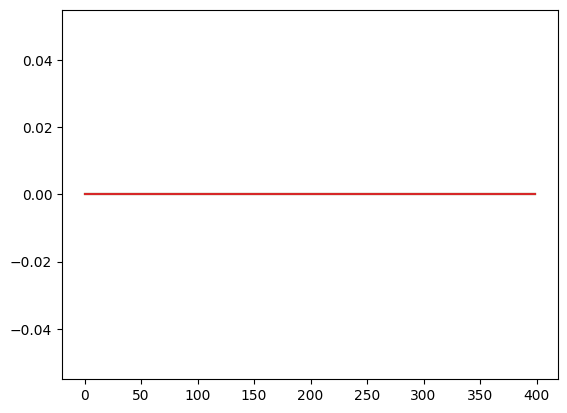

In [31]:
from matplotlib import pyplot as plt
for losses in steered_model.all_losses:
    plt.plot(losses)

In [148]:
model.layers[0]

AttributeError: 'GPT2LMHeadModel' object has no attribute 'layers'

In [98]:
import torch

# Input tensor
x = torch.randn(10, 1000)

x = x+x
# LayerNorm parameters
eps = 1e-5
gamma = torch.ones(x.size(1))  # Scale parameter
beta = torch.zeros(x.size(1))  # Shift parameter

# Calculate mean and variance
mean = x.mean(dim=-1, keepdim=True)
var = x.var(dim=-1, unbiased=False, keepdim=True)

# Normalize
x_norm = (x - mean) / torch.sqrt(var + eps)

# Apply scale and shift
out = gamma * x_norm + beta

In [99]:
out.shape

torch.Size([10, 1000])

In [100]:
x_norm.sum(dim=1)

tensor([-1.9073e-06,  6.6757e-06,  1.9073e-06, -8.5831e-06,  1.1683e-05,
         5.7220e-06, -1.0490e-05,  8.5831e-06,  1.5259e-05,  8.1062e-06])

In [101]:
x_norm.std(dim=1)

tensor([1.0005, 1.0005, 1.0005, 1.0005, 1.0005, 1.0005, 1.0005, 1.0005, 1.0005,
        1.0005])

In [102]:
x_norm.max(dim=1), x_norm.min(dim=1)

(torch.return_types.max(
 values=tensor([3.2839, 2.9169, 3.0958, 2.9471, 3.2258, 3.4723, 2.9237, 3.5378, 3.8970,
         2.6843]),
 indices=tensor([ 85, 401, 104, 923, 864, 796, 376, 186, 371, 907])),
 torch.return_types.min(
 values=tensor([-2.9796, -3.8673, -3.6160, -2.9578, -3.7202, -3.3747, -3.3288, -3.5810,
         -3.6232, -3.7342]),
 indices=tensor([ 77, 511,  35, 939, 483, 473, 743, 666,  15, 485])))

In [103]:
(x_norm[5]**2).sum()

tensor(999.9975)

(array([  3.,  17.,  67., 181., 259., 246., 148.,  59.,  13.,   7.]),
 array([-6.7209816 , -5.35251045, -3.98403978, -2.61556888, -1.24709797,
         0.12137294,  1.48984385,  2.85831475,  4.22678566,  5.59525681,
         6.96372747]),
 <BarContainer object of 10 artists>)

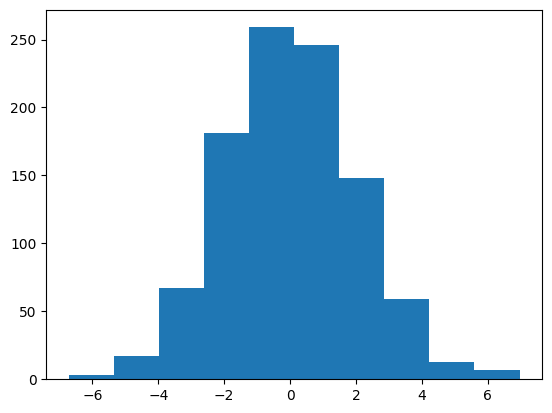

In [104]:
from matplotlib import pyplot as plt
plt.hist(x[5])

(array([  3.,  17.,  67., 181., 259., 246., 148.,  59.,  13.,   7.]),
 array([-3.37465167, -2.68995309, -2.00525451, -1.32055604, -0.63585752,
         0.048841  ,  0.73353952,  1.41823804,  2.10293651,  2.78763509,
         3.47233367]),
 <BarContainer object of 10 artists>)

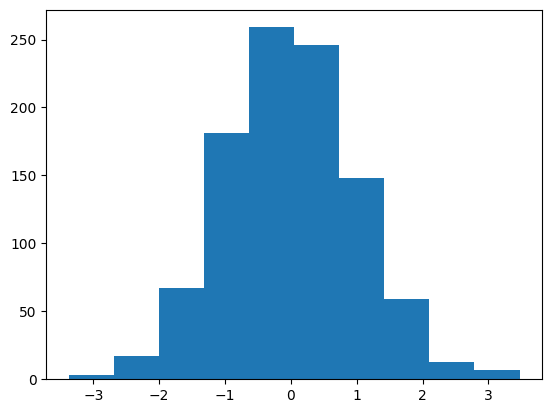

In [105]:
plt.hist(x_norm[5])

In [96]:
x_norm.norm(p=2, dim=1)

tensor([31.6226, 31.6226, 31.6226, 31.6226, 31.6226, 31.6226, 31.6226, 31.6226,
        31.6226, 31.6226])

In [131]:
import torch

# Define dimensions and target
dim_v = 100
dim_hidden = 100  # Example hidden dimension for W_1
dim_output = 100  # Example output dimension for W_2
R = 5.0  # Fixed norm of v

# Randomly initialize weights and target t*
W_1 = torch.randn(dim_hidden, dim_v, requires_grad=False)
W_2 = torch.randn(dim_output, dim_hidden, requires_grad=False)
t_star = torch.randn(dim_output)

# Initialize v and make it require gradients
v = torch.randn(dim_v, requires_grad=True)

# Define optimizer
optimizer = torch.optim.Adam([v], lr=0.01)

# Optimization loop
num_iterations = 5000
for i in range(num_iterations):
    optimizer.zero_grad()

    # Forward pass: compute t
    t = W_2 @ W_1 @ v

    # Objective: maximize the difference between t and t_star
    loss = -torch.norm(t - t_star)

    # Add Lagrange multiplier for the norm constraint
    norm_v = torch.norm(v)
    lagrange_penalty = 100 * (norm_v - R) ** 2  # Adjust the coefficient as needed
    total_loss = loss + lagrange_penalty

    # Backward pass and optimization step
    total_loss.backward()
    optimizer.step()

    # Enforce the norm constraint directly (optional)
    # with torch.no_grad():
    #     v *= R / torch.norm(v)

    # Print progress
    if (i + 1) % 500 == 0:
        print(f"Iteration {i + 1}/{num_iterations}, Loss: {total_loss.item()}, Norm of v: {torch.norm(v).item()}")

# Final optimized vector v
print("Optimized v:", v)

t_new = W_2 @ W_1 @ v

Iteration 500/5000, Loss: -1424.471923828125, Norm of v: 6.261987209320068
Iteration 1000/5000, Loss: -1429.1220703125, Norm of v: 6.267395973205566
Iteration 1500/5000, Loss: -1429.130615234375, Norm of v: 6.267739772796631
Iteration 2000/5000, Loss: -1429.130615234375, Norm of v: 6.267743110656738
Iteration 2500/5000, Loss: -1429.130859375, Norm of v: 6.26774263381958
Iteration 3000/5000, Loss: -1429.1307373046875, Norm of v: 6.267743110656738
Iteration 3500/5000, Loss: -1429.130615234375, Norm of v: 6.2677435874938965
Iteration 4000/5000, Loss: -1429.1307373046875, Norm of v: 6.267743110656738
Iteration 4500/5000, Loss: -1429.1307373046875, Norm of v: 6.2677435874938965
Iteration 5000/5000, Loss: -1429.130859375, Norm of v: 6.267775535583496
Optimized v: tensor([ 0.8890, -0.1086, -1.2399,  0.1648,  0.6315,  0.6349,  0.5438, -0.3695,
         0.3552,  0.1410, -1.1863,  0.2114,  1.0489, -0.1235, -0.2080, -0.6738,
        -0.1358, -0.1560,  0.9989, -0.5366, -1.0003,  0.1594,  0.1659,  

In [132]:
t_star

tensor([-6.4479e-01,  1.3086e+00,  1.6266e-01,  4.7902e-02, -5.3073e-01,
        -1.0046e+00,  1.5669e-01,  1.3425e+00,  2.0375e+00, -5.2938e-01,
        -9.8681e-01, -1.2539e+00, -9.2507e-01,  1.1909e+00, -2.5771e+00,
        -3.0444e-02,  1.0113e+00,  3.3005e-01,  5.6958e-01, -6.8066e-01,
         1.3758e+00, -2.8848e-01,  1.8559e+00, -1.5667e+00,  8.8062e-01,
        -4.1805e-02,  5.5047e-01, -5.0321e-01, -1.9003e+00, -1.3143e-01,
        -2.0310e+00, -9.4127e-01, -5.7364e-01,  4.0321e-03,  1.8609e-01,
        -5.0024e-01,  8.2924e-01,  3.3163e-01, -4.6382e-01, -5.3208e-01,
        -1.8807e+00, -7.1218e-01,  5.3786e-02,  3.0992e-01, -1.9487e-01,
        -5.2937e-04, -1.2048e+00, -1.8905e-01,  1.6135e+00,  5.1573e-01,
         3.2072e-01, -2.3501e+00,  1.7469e+00,  2.0085e+00,  9.3275e-01,
         1.1421e+00,  4.5029e-01, -1.0799e+00, -3.1809e-01,  9.2592e-01,
        -5.3877e-01,  3.2450e-01, -9.5594e-02, -6.0497e-01, -1.3518e+00,
        -3.8346e-01,  3.2404e-01, -2.1176e-01, -1.0

In [135]:
# dot = ||v||*||u||*cos(a)
# cos(a) = dot(v,u)*||v||*||u||
(t_new@t_star)/(t_new.norm())

tensor(-947.3406, grad_fn=<DotBackward0>)

In [138]:
t_new.norm()

tensor(1589.2230, grad_fn=<LinalgVectorNormBackward0>)

In [139]:
t_star.norm()

tensor(10.8813)